# Analyses de données

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.feature_selection import SelectKBest, f_regression
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test



# Lecture du dataset et mise en forme

In [2]:
df = pd.read_csv('projet.csv', 
    na_values="?",        # Treat '?' as missing values (NaN).
    comment="\t",         # Lines starting with tab ("\t") are comments. Ignore.
    sep=",",              # Use comma as a separator.
    skipinitialspace=True,# Skip initial spaces in the data.
)

 2 Clean the Dataset

In [3]:
# Supprime  les escpaces vides gauche et droite de chaque valeur dans le DataFrame
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)
df["Overall Survival Status"] = df["Overall Survival Status"].map({"Living": False, "Deceased": True})

# Supprimer les données qui non pas de target
df.dropna(subset=["Overall Survival (Months)"], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1981 entries, 0 to 1984
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Patient ID                      1981 non-null   object 
 1   Age at Diagnosis                1981 non-null   float64
 2   Type of Breast Surgery          1955 non-null   object 
 3   Cancer Type                     1981 non-null   object 
 4   Cancer Type Detailed            1981 non-null   object 
 5   Cellularity                     1917 non-null   object 
 6   Chemotherapy                    1980 non-null   object 
 7   Pam50 + Claudin-low subtype     1980 non-null   object 
 8   Cohort                          1981 non-null   float64
 9   ER status measured by IHC       1938 non-null   object 
 10  ER Status                       1981 non-null   object 
 11  Neoplasm Histologic Grade       1893 non-null   float64
 12  HER2 status measured by SNP6    1980 no

In [4]:
# Sélectionner uniquement les colonnes Numeriques
num_columns = df.select_dtypes(exclude=['object', 'category']).columns
cat_columns = df.select_dtypes(include=['object', 'category']).columns
print(f'Nombre de données numériques : {len(num_columns)}', f'Nombre de données catégorielles : {len(cat_columns)}', sep='\n')

Nombre de données numériques : 10
Nombre de données catégorielles : 24


In [5]:
from sklearn.experimental import enable_iterative_imputer
from scipy.stats import chi2_contingency
from sklearn.impute import IterativeImputer 
from sklearn.impute import KNNImputer

def impute_missing_values(X_num, type_imputer="MICE"):
    if type_imputer == "MICE":
        imputer = IterativeImputer()
    else:
        imputer = KNNImputer(n_neighbors=5)
    X_imputed = imputer.fit_transform(X_num)

    return pd.DataFrame(X_imputed, columns=X_num.columns)


def chi2_scores(df, target):
    scores = {}
    for col in df.select_dtypes(include=['object', 'category']).columns:
        contingency = pd.crosstab(df[col], df[target])
        chi2, p, dof, ex = chi2_contingency(contingency)
        scores[col] = p
    return pd.Series(scores).sort_values()

## Analyse des donné de sortie

In [6]:
#Statistique sur la durée de survie
df[["Overall Survival (Months)", "Relapse Free Status (Months)"]].describe()

,Overall Survival (Months),Relapse Free Status (Months)
count,1981.000000,1981.000000
mean,125.244271,110.072887
std,76.111772,76.309194
min,0.000000,0.000000
25%,60.866667,41.740000
50%,116.466667,100.720000
75%,185.133333,167.600000
max,355.200000,346.380000


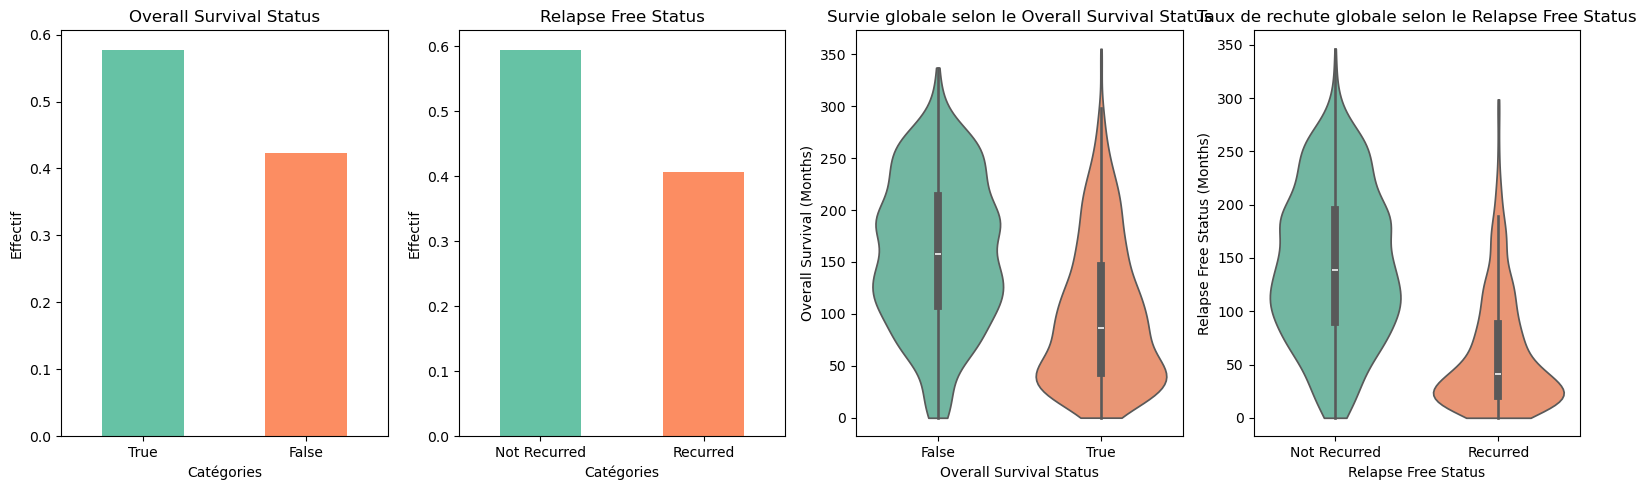

In [7]:
# Extimer la proportion de personne censurer

out_state = ["Overall Survival Status", "Relapse Free Status"]
plt.figure(figsize=(16, 5))
for i, var in enumerate(out_state, 1):
    plt.subplot(1, 4, i)
    df[var].value_counts(normalize=True).plot(kind='bar', color=sns.color_palette("Set2"))
    plt.title(var)
    plt.xlabel("Catégories")
    plt.ylabel("Effectif")
    plt.xticks(rotation=0, ha='center')

plt.subplot(1, 4, 3)
sns.violinplot( data=df, x="Overall Survival Status", y="Overall Survival (Months)", hue="Overall Survival Status", palette="Set2", legend=False, cut=0 ) 
plt.title("Survie globale selon le Overall Survival Status") 
plt.xlabel("Overall Survival Status") 
plt.ylabel("Overall Survival (Months)")

plt.subplot(1, 4, 4)
sns.violinplot( data=df, x="Relapse Free Status", y="Relapse Free Status (Months)", hue="Relapse Free Status", palette="Set2", legend=False, cut=0 ) 
plt.title("Taux de rechute globale selon le Relapse Free Status") 
plt.xlabel("Relapse Free Status") 
plt.ylabel("Relapse Free Status (Months)")

plt.tight_layout()
plt.show()

# Model avec données numerique
Une inspection approfondie du dataset a révélé que certaines variables initialement typées comme numériques étaient en réalité catégorielles (valeurs discrètes, non continues, sans signification ordinale). Afin d’éviter d’introduire du bruit ou des biais dans le modèle de survie, seules les vraies variables catégorielles ont été retenues.

1. Mutation Count (Charge Mutationnelle)
* Lien Clinique : Reflet de l'instabilité génomique. Plus le score est élevé, plus la tumeur est hétérogène et potentiellement agressive.
* Impact Cox : Attention au risque d'overfitting si traitée en purement catégoriel. On la préfère souvent en numérique discret ou log-transformée pour stabiliser les Hazard Ratios (HR).
* 𝑋 = log⁡(1 + Mutation Count)

2. Lymph Nodes Examined Positive (Envahissement Ganglionnaire)
* Lien Clinique : C'est le "péage" du cancer. S'il y a des cellules ici, la dissémination systémique a commencé. C'est l'un des prédicteurs les plus puissants.
* Impact Cox : Relation souvent non-linéaire. Le regroupement en classes (0, 1-3, >3) est plus robuste pour satisfaire l'hypothèse des risques proportionnels.
* L’avantage clinique : C'est ainsi que les oncologues réfléchissent (Stades N0, N1, N2).
* L’avantage Data : Cela permet de capturer des effets non-linéaires. Le modèle peut alors dire : "Avoir au moins un ganglion multiplie le risque par 3, mais en avoir plus de 3 le multiplie par 10".

3. Nottingham prognostic index(estimer la survie à long terme après le diagnostic)
* Lien Clinique : Le "Gold Standard". Il combine taille, grade et ganglions. 
    * ≤ 3.4	Bon	survie élevée, 3.4 – 5.4	Intermédiaire	survie moyenne, > 5.4	Mauvais	survie faible
$$ NPI=(0.2×taille de la tumeur en cm)+grade histologique+score ganglions lymphatiques $$
* Impact Cox : Variable continue idéale. Attention : Ne pas inclure les ganglions et la taille de la tumeur en plus du NPI dans le même modèle pour éviter la multicolinéarité.

4. Age at diagnosis
* Lien Clinique : Facteur de confusion majeur. Les patientes très jeunes ou très âgées ont souvent des profils de survie distincts.
* Impact Cox : Sert souvent de variable de contrôle. On vérifie l'absence d'effet de cohorte.

5. Variables de sortie (survival outcomes)
* Overall Survival (Months) -> Temps écoulé jusqu'au décès (toutes causes).
* Overall Survival Status -> 0 : Censuré (vivant)
* Relapse Free Status -> Mesure l'efficacité réelle du traitement avant récidive.
* Vital Status -> Permet de distinguer les décès liés au cancer (Modèle de Risques Compétitifs).

In [8]:
num_columns = ["Mutation Count", "Nottingham prognostic index", "Lymph nodes examined positive", "Age at Diagnosis", "Overall Survival (Months)", "Relapse Free Status (Months)"]
df_num = df[num_columns]
X_num = df_num.drop(columns=["Overall Survival (Months)", "Relapse Free Status (Months)"])

# Faire iputation sur les données numériques manquantes
X_imputed = impute_missing_values(X_num, type_imputer = "MICE")
X_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1981 entries, 0 to 1980
Data columns (total 4 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Mutation Count                 1981 non-null   float64
 1   Nottingham prognostic index    1981 non-null   float64
 2   Lymph nodes examined positive  1981 non-null   float64
 3   Age at Diagnosis               1981 non-null   float64
dtypes: float64(4)
memory usage: 62.0 KB


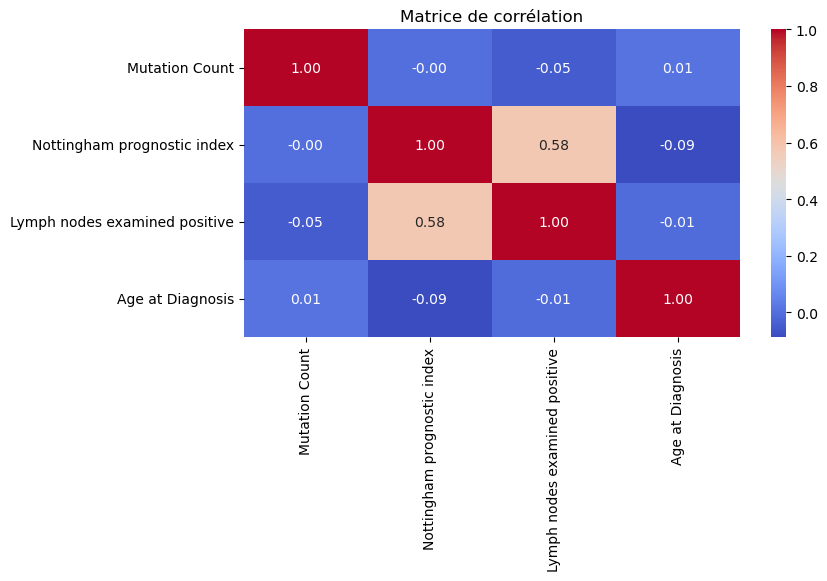

In [9]:
# Calcul de la matrice de corrélation
corr_matrix = X_imputed.corr()

# Affichage de la heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

#sns.pairplot(X_imputed)
#plt.show()

In [10]:
# preparation de la target
y = df_num["Overall Survival (Months)"]
selector = SelectKBest(score_func=f_regression, k="all")
selector.fit(X_imputed, y)

scores = pd.DataFrame({
    "Variable": X_imputed.columns,
    "Score": selector.scores_
}).sort_values(by="Score", ascending=False)

print("Scores de pertinence :")
print(scores)

Scores de pertinence :
                        Variable       Score
1    Nottingham prognostic index  122.296734
2  Lymph nodes examined positive  120.920147
3               Age at Diagnosis   42.984209
0                 Mutation Count    3.277544


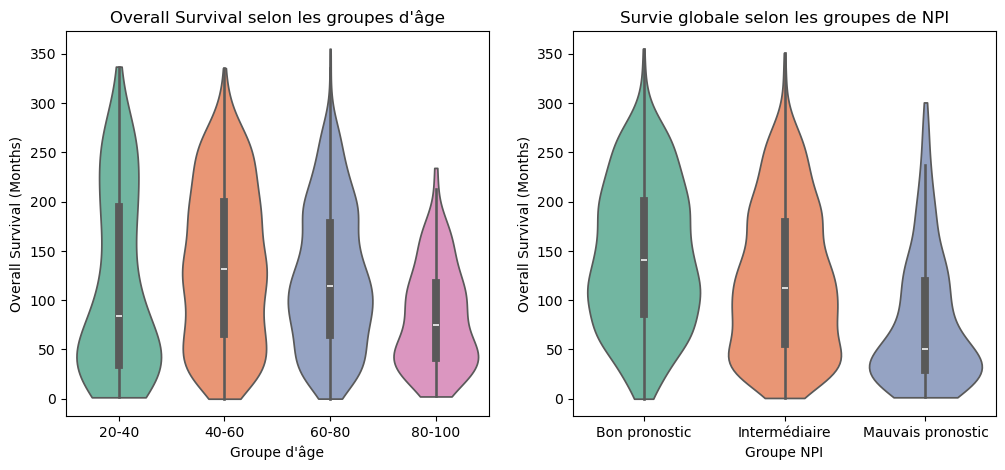

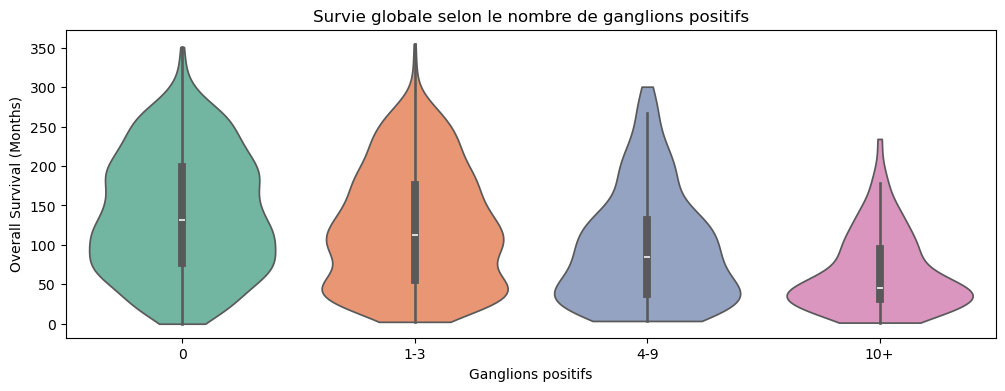

In [11]:
bins = [20, 40, 60, 80, 100]
bins_npi = [0, 3.4, 5.4, 10]
bins_nodes = [-1, 0, 3, 9, 50]
labels = ["20-40", "40-60", "60-80", "80-100"]
labels_npi = ["Bon pronostic", "Intermédiaire", "Mauvais pronostic"]
labels_nodes = ["0", "1-3", "4-9", "10+"]

df["Age_group"] = pd.cut(df["Age at Diagnosis"], bins=bins, labels=labels, include_lowest=True)
df["NPI_group"] = pd.cut(df["Nottingham prognostic index"], bins=bins_npi, labels=labels_npi)
df["Nodes_group"] = pd.cut(df["Lymph nodes examined positive"], bins=bins_nodes, labels=labels_nodes)

plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
sns.violinplot(data=df, x="Age_group",  y="Overall Survival (Months)", hue="Age_group", palette="Set2", legend=False, cut=0)
plt.title("Overall Survival selon les groupes d'âge")
plt.xlabel("Groupe d'âge")
plt.ylabel("Overall Survival (Months)")

plt.subplot(1, 2, 2)
sns.violinplot( data=df, x="NPI_group", y="Overall Survival (Months)", hue="NPI_group", palette="Set2", legend=False, cut=0 ) 
plt.title("Survie globale selon les groupes de NPI") 
plt.xlabel("Groupe NPI") 
plt.ylabel("Overall Survival (Months)")
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(12,4))
sns.violinplot( data=df, x="Nodes_group", y="Overall Survival (Months)", hue="Nodes_group", palette="Set2", legend=False, cut=0 ) 
plt.title("Survie globale selon le nombre de ganglions positifs") 
plt.xlabel("Ganglions positifs") 
plt.ylabel("Overall Survival (Months)")

plt.xticks(rotation=0)
plt.show()

#  Variables catégorielle

C'est ici que ton modèle de Cox va prendre toute sa profondeur. Les variables catégorielles en oncologie ne sont pas juste des étiquettes : elles définissent l'identité moléculaire de la tumeur et la stratégie thérapeutique.
Pour le modèle de Cox, la règle d'or est le One-Hot Encoding (variables dummy) en choisissant toujours une catégorie de référence biologiquement sensée.

## 🧬 Identité Moléculaire : Le "Cœur" du Pronostic

1. PAM50 + Claudin-low Subtype
* Lien Clinique : C'est la carte d'identité génétique (Luminal A, B, Her2+, Basal, Claudin-low). Le Luminal A est généralement de bon pronostic, tandis que le Basal (souvent triple négatif) est très agressif.
* Impact Cox : La variable la plus prédictive.
    * Stratégie : Utiliser Luminal A comme catégorie de référence. Les HR des autres sous-types s'interpréteront comme un "sur-risque" par rapport au groupe le plus favorable.

2. ER, PR et HER2 Status
* Lien Clinique : Les trois piliers de la décision thérapeutique. ER+/PR+ signifie que la tumeur est hormono-dépendante (sensible à l'hormonothérapie). HER2+ indique une amplification génétique nécessitant des thérapies ciblées.
* Impact Cox : Variables binaires (Positif/Négatif). Elles sont extrêmement stables dans un modèle de Cox.
* Attention : Vérifie la concordance entre ER_status_IHC et les sous-types PAM50 pour éviter les redondances massives.

3. Integrative Cluster (IntClust)
* Lien Clinique : Une classification spécifique au dataset METABRIC qui regroupe les patientes selon les altérations génomiques (CNV) et l'expression génique (10 clusters).
* Impact Cox : Très granulaire.
* Attention : Certains clusters ont peu d'effectifs. Regroupe les clusters rares si nécessaire pour éviter des intervalles de confiance trop larges sur tes HR.

In [12]:
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2, p, dof, expected = chi2_contingency(table)
    n = table.sum().sum()
    phi2 = chi2 / n
    r, k = table.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

In [13]:
moleculars = ['ER status measured by IHC', "HER2 status measured by SNP6", "PR Status", 'Integrative Cluster']

for k, molecular in enumerate(moleculars):
    cv = cramers_v(df[molecular], df['Pam50 + Claudin-low subtype'])
    if cv > 0.5:
        print(f'variable {molecular} {cv:.3f}: quasi‑redondance (colinéarité probable)')
    else:
        print(f'variable {molecular} {cv:.3f}: association modérée')

variable ER status measured by IHC 0.686: quasi‑redondance (colinéarité probable)
variable HER2 status measured by SNP6 0.237: association modérée
variable PR Status 0.522: quasi‑redondance (colinéarité probable)
variable Integrative Cluster 0.429: association modérée


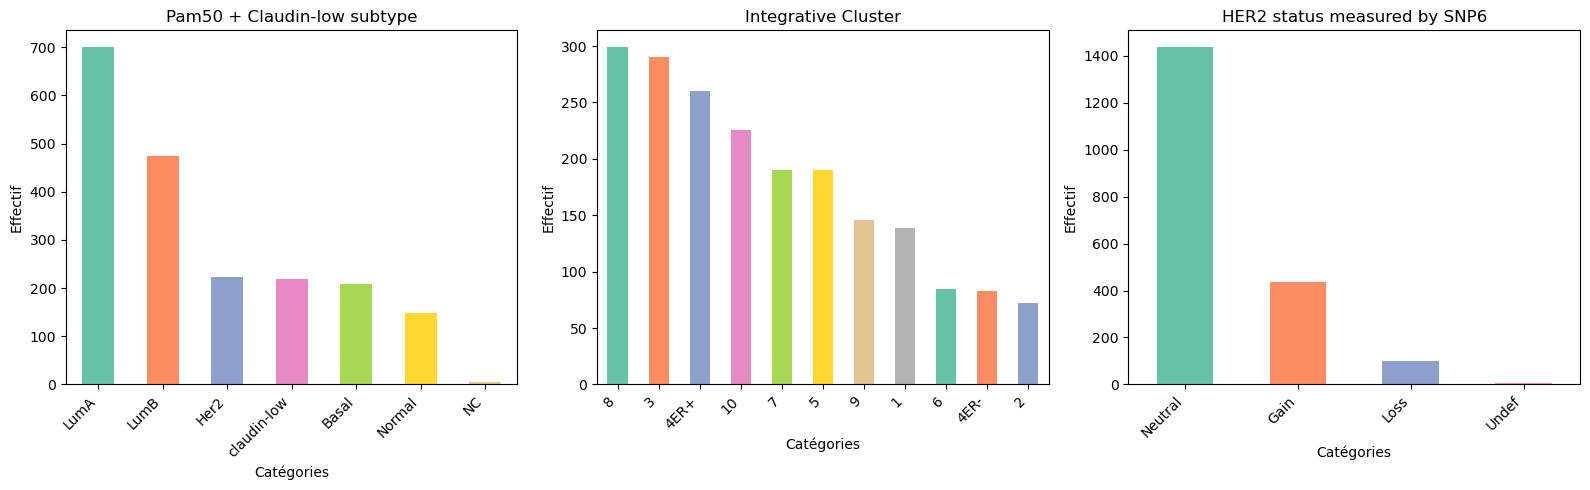

In [14]:
variables_moleculaire = [
    'Pam50 + Claudin-low subtype',
    'Integrative Cluster',
    'HER2 status measured by SNP6' #Limit hummmmmm
]

plt.figure(figsize=(16, 5))
for i, var in enumerate(variables_moleculaire, 1):
    plt.subplot(1, 3, i)
    df[var].value_counts().plot(kind='bar', color=sns.color_palette("Set2"))
    plt.title(var)
    plt.xlabel("Catégories")
    plt.ylabel("Effectif")
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### 🏥 Traitements et Contexte : L'intervention médicale

4. Chemotherapy & Radio Therapy
* Lien Clinique : Indique si la patiente a reçu un traitement systémique ou local.
* Impact Cox : Attention, biais de sélection ! En clinique, on donne de la chimio aux cas les plus graves. Si ton modèle dit que la chimio "augmente" le risque de décès, c'est simplement parce qu'elle a été administrée aux patientes les plus à risque (biais d'indication).
* Conseil : Utilise-les comme variables d'ajustement, mais interprète-les avec prudence.

5. Type of Breast Surgery
* Lien Clinique : Mastectomie (ablation totale) vs Breast Conserving (ablation partielle).
* Impact Cox : Souvent corrélé à la taille de la tumeur. Si la tumeur est grosse, on fait une mastectomie.
* Stratégie : Comme pour le NPI, attention à la colinéarité avec la taille de la tumeur.

6. Inferred Menopausal State
* Lien Clinique : Reflet de l'imprégnation hormonale. Le pronostic et le choix des molécules (Tamoxifène vs Inhibiteurs de l'aromatase) changent radicalement avant/après la ménopause.
* Impact Cox : Souvent corrélé à l'âge, mais apporte une information biologique supplémentaire sur l'environnement endocrinien.

variable Chemotherapy 0.229: association modérée
variable Type of Breast Surgery 0.505: quasi‑redondance (colinéarité probable)
variable Inferred Menopausal State 0.068: association modérée
variable Radio Therapy 0.999: quasi‑redondance (colinéarité probable)


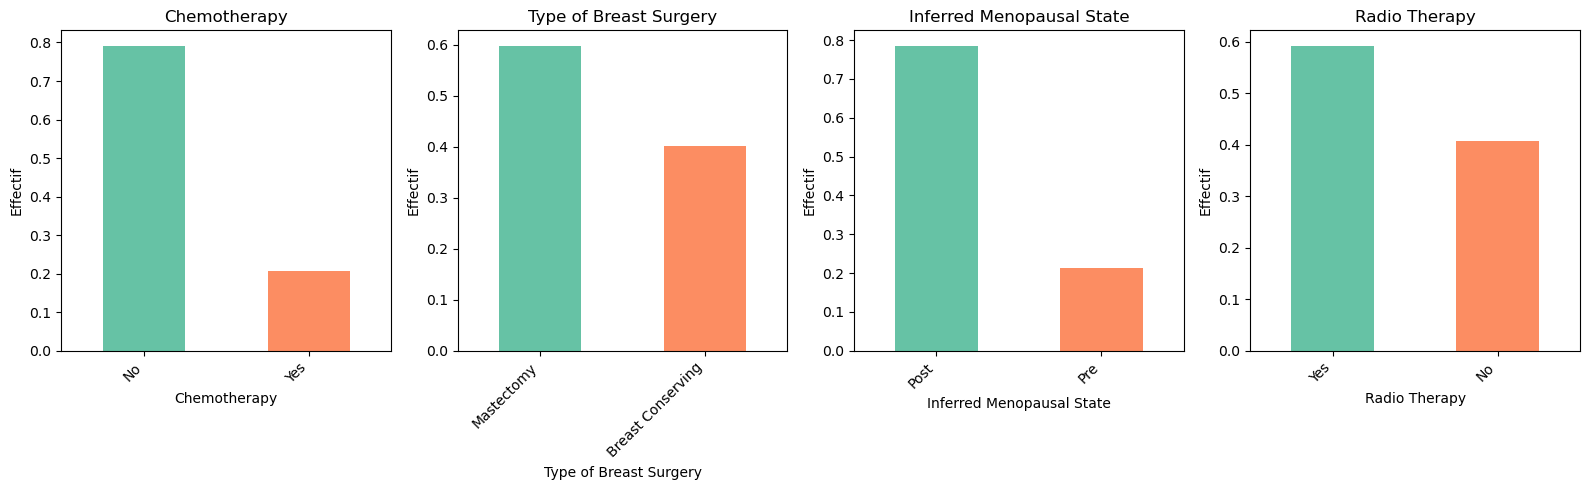

In [15]:
treatments =  ["Chemotherapy", "Type of Breast Surgery", "Inferred Menopausal State", "Radio Therapy"]

for k, treatment in enumerate(treatments):
    cv = cramers_v(df[treatment], df["Radio Therapy"])
    if cv > 0.5:
        print(f'variable {treatment} {cv:.3f}: quasi‑redondance (colinéarité probable)')
    else:
        print(f'variable {treatment} {cv:.3f}: association modérée')

plt.figure(figsize=(16, 5))
for i, var in enumerate(treatments, 1):
    plt.subplot(1, 4, i)
    df[var].value_counts(normalize=True).plot(kind='bar', color=sns.color_palette("Set2"))
    plt.title(var)
    plt.ylabel("Effectif")
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

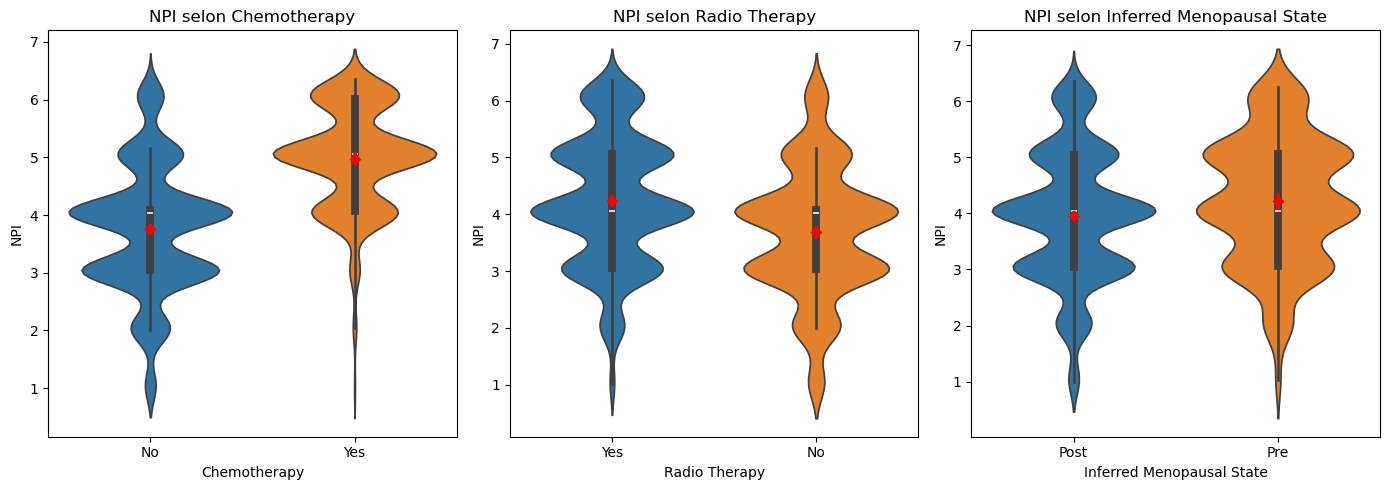

In [16]:
plt.figure(figsize=(14, 5))

# Boxplot NPI ~ Chemotherapy
plt.subplot(1, 3, 1)
sns.violinplot(data=df, x='Chemotherapy', y='Nottingham prognostic index', hue='Chemotherapy', legend=False)
#sns.boxplot(data=df, x='Chemotherapy', y='Nottingham prognostic index', hue='Chemotherapy', palette='Set2', legend=False)
sns.pointplot( data=df, x='Chemotherapy', y='Nottingham prognostic index', estimator='mean', color='red', markers='D', markersize=4, linestyle='none')
plt.title("NPI selon Chemotherapy")
plt.xlabel("Chemotherapy")
plt.ylabel("NPI")

plt.subplot(1, 3, 2)
sns.violinplot(data=df, x="Radio Therapy", y='Nottingham prognostic index', hue="Radio Therapy", legend=False)
sns.pointplot( data=df, x="Radio Therapy", y='Nottingham prognostic index', estimator='mean', color='red', markers='D', markersize=4, linestyle='none')
plt.title("NPI selon Radio Therapy")
plt.xlabel("Radio Therapy")
plt.ylabel("NPI")

plt.subplot(1, 3, 3)
sns.violinplot(data=df, x="Inferred Menopausal State", y='Nottingham prognostic index', hue="Inferred Menopausal State", legend=False)
sns.pointplot( data=df, x="Inferred Menopausal State", y='Nottingham prognostic index', estimator='mean', color='red', markers='D', markersize=4, linestyle='none')
plt.title("NPI selon Inferred Menopausal State")
plt.xlabel("Inferred Menopausal State")
plt.ylabel("NPI")

plt.tight_layout()
plt.show()

## 🔬 les variables de morphologie et d'architecture tumorale.

L'Architecture du Mal : Grade, Stade et Cellularité

1. Neoplasm Histologic Grade (Grade de Scarff-Bloom-Richardson)
* Lien Clinique : C'est le degré de "différenciation" des cellules.
    * Grade 1 : Les cellules ressemblent encore à des cellules normales (bien différenciées).
    * Grade 3 : C'est l'anarchie totale, les cellules se divisent vite et ne ressemblent plus à rien (indifférenciées).
* Impact Cox : Le grade 3 est un prédicteur de survie à court terme très puissant.
    * Conseil d'expert : Bien que numérique (1, 2, 3), traite-le comme catégoriel ordinal. Le saut de risque entre le grade 2 et 3 est souvent bien plus brutal qu'entre le 1 et le 2.

2. Tumor Stage (Stades TNM)
* Lien Clinique : C'est l'extension anatomique de la maladie. Du stade 0 (in situ) au stade 4 (métastatique).
* Impact Cox : C'est ta variable de "gravité spatiale".
    * Pièce jointe Clinique : Le stade 4 est souvent un "outlier" de survie (risque extrêmement élevé). Si tu as peu de patientes en stade 4, le modèle risque d'avoir des coefficients avec des écarts-types énormes.
    * Stratégie Data : Vérifie l'effectif du stade 4. S'il est trop faible, on le regroupe parfois avec le stade 3 pour stabiliser le modèle.

3. Cellularity (Densité Tumorale)
* Lien Clinique : Proportion de cellules cancéreuses par rapport au stroma (tissu de soutien) dans l'échantillon.
* Impact Cox : Variable plus subtile. Une cellularité "High" peut signifier une tumeur très dense et agressive, mais elle rend aussi l'extraction d'ADN/ARN plus fiable pour les analyses génomiques.
* Traitement : ['Low', 'Moderate', 'High']. C'est une échelle qualitative. Dans Cox, on utilise souvent 'Low' comme référence pour voir si la densité tumorale augmente le risque de manière linéaire.


In [17]:
morphologies =  ["Neoplasm Histologic Grade", "Tumor Stage", "Cellularity"]

for k, morphologie in enumerate(morphologies):
    cv = cramers_v(df[morphologie], df["Neoplasm Histologic Grade"])
    if cv > 0.5:
        print(f'variable {morphologie} {cv:.3f}: quasi‑redondance (colinéarité probable)')
    else:
        print(f'variable {morphologie} {cv:.3f}: association modérée')

variable Neoplasm Histologic Grade 1.000: quasi‑redondance (colinéarité probable)
variable Tumor Stage 0.140: association modérée
variable Cellularity 0.065: association modérée


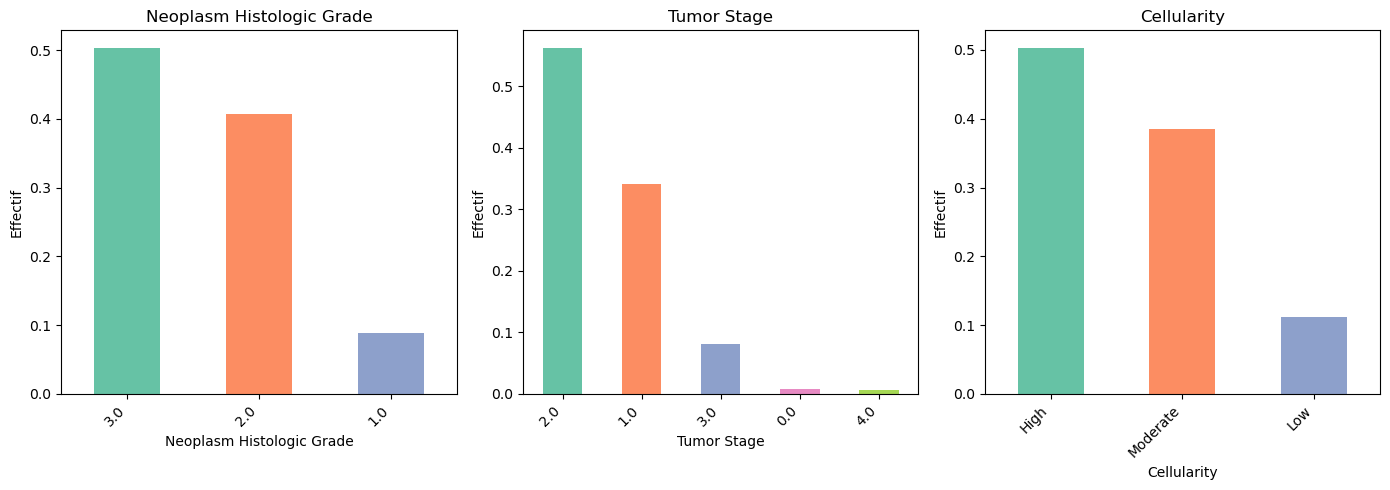

In [18]:
plt.figure(figsize=(14, 5))
for i, var in enumerate(morphologies, 1):
    plt.subplot(1, 3, i)
    df[var].value_counts(normalize=True).plot(kind='bar', color=sns.color_palette("Set2"))
    plt.title(var)
    plt.ylabel("Effectif")
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

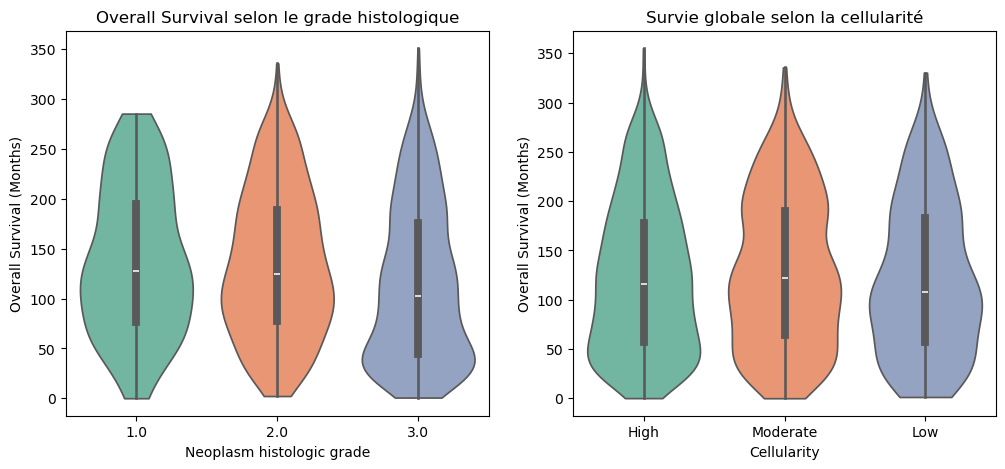

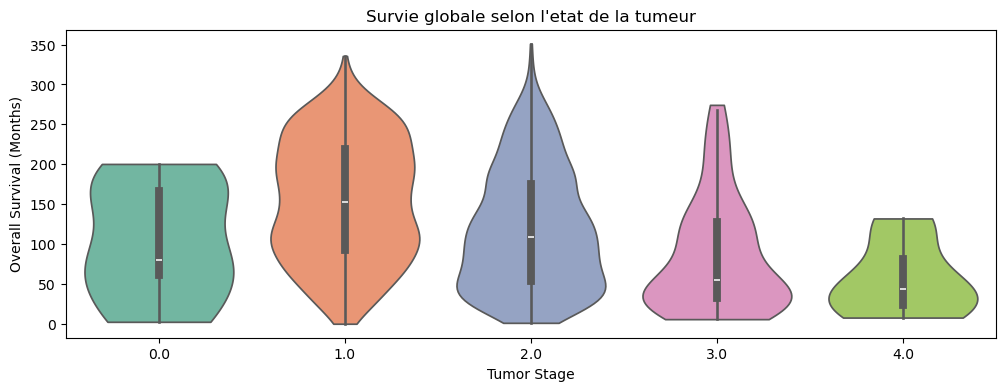

In [19]:
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
sns.violinplot(data=df, x=morphologies[0],  y="Overall Survival (Months)", hue=morphologies[0], palette="Set2", legend=False, cut=0)
plt.title("Overall Survival selon le grade histologique")
plt.xlabel("Neoplasm histologic grade")
plt.ylabel("Overall Survival (Months)")

plt.subplot(1, 2, 2)
sns.violinplot( data=df, x=morphologies[2], y="Overall Survival (Months)", hue=morphologies[2], palette="Set2", legend=False, cut=0 ) 
plt.title("Survie globale selon la cellularité") 
plt.xlabel(morphologies[2]) 
plt.ylabel("Overall Survival (Months)")
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(12,4))
sns.violinplot( data=df, x=morphologies[1], y="Overall Survival (Months)", hue=morphologies[1], palette="Set2", legend=False, cut=0 ) 
plt.title("Survie globale selon l'etat de la tumeur") 
plt.xlabel(morphologies[1]) 
plt.ylabel("Overall Survival (Months)")

plt.xticks(rotation=0)
plt.show()

In [ ]:
def km_by_group(df, time_col, event_col, group_col):
    print(f"\n===== Kaplan-Meier : {group_col} =====")

    # Convertir en numérique
    df = df.copy()
    df[time_col] = pd.to_numeric(df[time_col], errors="coerce")
    df[event_col] = pd.to_numeric(df[event_col], errors="coerce")

    # Supprimer les lignes invalides
    df_clean = df.dropna(subset=[time_col, event_col, group_col])

    groups = df_clean[group_col].unique()
    km = KaplanMeierFitter()

    plt.figure(figsize=(8,6))

    for g in groups:
        mask = df_clean[group_col] == g

        if mask.sum() == 0:
            print(f"⚠️ Groupe '{g}' ignoré (aucune donnée valide).")
            continue

        km.fit(df_clean[time_col][mask], df_clean[event_col][mask], label=str(g))
        km.plot()

    plt.title(f"Courbes de survie selon {group_col}")
    plt.xlabel("Temps (mois)")
    plt.ylabel("Probabilité de survie")
    plt.grid(True)
    plt.show()

    # Log-rank test si 2 groupes
    if len(groups) == 2:
        g1, g2 = groups
        mask1 = df_clean[group_col] == g1
        mask2 = df_clean[group_col] == g2

        result = logrank_test(
            df_clean[time_col][mask1], df_clean[time_col][mask2],
            df_clean[event_col][mask1], df_clean[event_col][mask2]
        )
        print("\nLog-rank test :")
        print(result)



===== Kaplan-Meier : Inferred Menopausal State =====


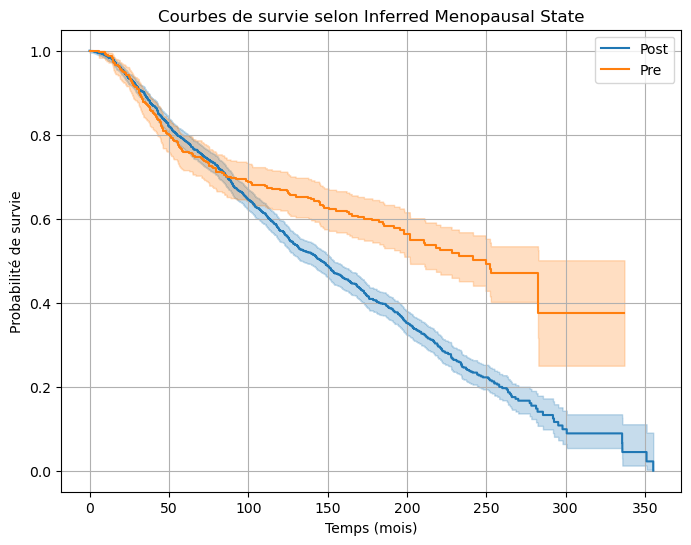


Log-rank test :
<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
          40.35 <0.005     32.13


In [21]:
km_by_group(df, "Overall Survival (Months)",  "Overall Survival Status", "Inferred Menopausal State")